In [9]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestClassifier
from category_encoders import TargetEncoder
from sklearn.neighbors import KNeighborsClassifier

In [54]:
a=pd.read_csv("cleaned_train_data.csv")
b=pd.read_csv("cleaned_test_data.csv")

In [72]:
df1 = a.drop(columns=["trans_num","first","last","street","zip","unix_time","merchant","lat","long","merch_lat","merch_long","cc_num","state","date","time"],axis=1)
df2 = b.drop(columns=["trans_num","first","last","street","zip","unix_time","merchant","lat","long","merch_lat","merch_long","cc_num","state","date","time"],axis=1)


In [73]:
df = pd.concat([df1, df2])

In [74]:
df.head()

,category,amt,gender,city,city_pop,job,is_fraud,age
0,misc_net,4.97,F,Moravian Falls,3495,"Psychologist, counselling",0,37
1,grocery_pos,107.23,F,Orient,149,Special educational needs teacher,0,47
2,entertainment,220.11,M,Malad City,4154,Nature conservation officer,0,63
3,gas_transport,45.00,M,Boulder,1939,Patent attorney,0,58
4,misc_pos,41.96,M,Doe Hill,99,Dance movement psychotherapist,0,39


In [75]:
df = df.drop_duplicates()

In [69]:
df["is_fraud"].value_counts()

is_fraud
0    1794484
1       9649
Name: count, dtype: int64

In [82]:
from sklearn.model_selection import train_test_split

y = df['is_fraud']
X = df.drop('is_fraud', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Preprocessing data with the new pipeline...
Preprocessing complete.

Applying SMOTE to the training data...
Class distribution before SMOTE: Counter({0: 1435612, 1: 7694})
Preprocessing complete.

Applying SMOTE to the training data...
Class distribution before SMOTE: Counter({0: 1435612, 1: 7694})


c:\Users\admin\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\imblearn\over_sampling\_smote\base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(


Class distribution after SMOTE: Counter({0: 1435612, 1: 1435612})

Training RandomForestClassifier...
Training complete.

--- Final Model Evaluation ---
Training complete.

--- Final Model Evaluation ---
Test Accuracy: 0.9964

Classification Report:
Test Accuracy: 0.9964

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    358872
           1       0.64      0.74      0.69      1955

    accuracy                           1.00    360827
   macro avg       0.82      0.87      0.84    360827
weighted avg       1.00      1.00      1.00    360827


Confusion Matrix:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    358872
           1       0.64      0.74      0.69      1955

    accuracy                           1.00    360827
   macro avg       0.82      0.87      0.84    360827
weighted avg       1.00      1.00      1.00    360827


Confusion Matrix:


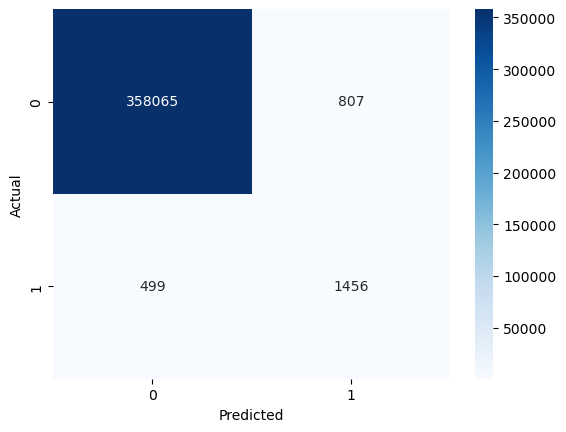

In [83]:

import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from imblearn.over_sampling import SMOTE
from category_encoders import TargetEncoder
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Define the Preprocessing Pipeline ---

# Define column groups
target_enc_cols = ["city", "job"]
label_enc_cols = ["category", "gender"]
num_cols = ["city_pop", "amt", "age"]

# Create a transformer for encoding categorical columns.
# We add regularization to TargetEncoder to prevent overfitting.
encoders_only = ColumnTransformer(
    transformers=[
        ('target_enc', TargetEncoder(cols=target_enc_cols, smoothing=10, min_samples_leaf=20), target_enc_cols),
        ('label_enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), label_enc_cols)
    ],
    remainder='passthrough'  # This keeps the numeric columns for the next step
)

# Create the full preprocessing pipeline.
# It first encodes all relevant columns, then scales the entire resulting dataset.
full_preprocessor = Pipeline(steps=[
    ('encoders', encoders_only),
    ('scaler', StandardScaler())
])


# --- Step 2: Preprocess Data and Apply SMOTE to Training Set ---
print("Preprocessing data with the new pipeline...")
# Fit the preprocessor on the training data and transform both train and test
X_train_processed = full_preprocessor.fit_transform(X_train, y_train)
X_test_processed = full_preprocessor.transform(X_test)
print("Preprocessing complete.")

# Apply SMOTE **only on the training data** to prevent data leakage
print("\nApplying SMOTE to the training data...")
print("Class distribution before SMOTE:", Counter(y_train))
smote = SMOTE(random_state=42, n_jobs=-1)
X_res, y_res = smote.fit_resample(X_train_processed, y_train)
print("Class distribution after SMOTE:", Counter(y_res))


# --- Step 3: Train and Evaluate the RandomForest Model ---
print("\nTraining RandomForestClassifier...")
# Use the RandomForestClassifier for better performance
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_res, y_res)
print("Training complete.")

# Evaluate on the untouched, correctly preprocessed test data
print("\n--- Final Model Evaluation ---")
y_pred = model.predict(X_test_processed)
score = model.score(X_test_processed, y_test)
print(f"Test Accuracy: {score:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [86]:
import pickle

# Save the fitted preprocessor
with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(full_preprocessor, f)



print("Preprocessor and model saved successfully as .pkl files.")

Preprocessor and model saved successfully as .pkl files.


In [84]:
# storing the best model in pickle file
import pickle

with open('Fraud_Detection_Model.pkl', 'wb') as file: # wb is write binary mode
    pickle.dump(model, file)